# Environment Setup

In [ ]:
# %pip install torch
# %conda activate torchenv
import torch
import torch.nn.functional as F
import numpy as np
import seaborn as sns
# %pip install colorcet
import colorcet as cc
import matplotlib.pyplot as plt
from sklearn.cluster import *
# %pip install captum
import captum
# %pip install cartopy
from PIL import Image
import torchvision
from torchvision import transforms
import os
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams["mathtext.fontset"]= 'cm'  # Use Computer Modern for math
plt.rc('axes', labelsize=28, titlesize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

In [ ]:
# Set working directory to where ImageNet data is stored
%cd C:/Your/Path/To/ImageNet

C:\Users\10233\Box\Research\Data\ImageNet


## Utilities

In [ ]:
def load_jpeg_images(directory):
    """Loads JPEG images from a directory into a list of PIL Image objects.

    Args:
        directory: The path to the directory containing the JPEG images.

    Returns:
        A list of PIL Image objects, or None if an error occurs.
    """
    image_list = []
    try:
        for filename in os.listdir(directory):
            if filename.lower().endswith(".jpg") or filename.lower().endswith(".jpeg"):
                filepath = os.path.join(directory, filename)
                try:
                    img = Image.open(filepath)
                    image_list.append(img)
                except IOError:
                    print(f"Error opening image file: {filepath}")
                    # Handle the error appropriately (e.g., skip the file or raise an exception)

    except FileNotFoundError:
        print(f"Directory not found: {directory}")
        return None

    print(f"Loaded {len(image_list)} images.")
    return image_list

def image_to_3d_array(image):
    """Converts a PIL Image object to a 3D NumPy array.

    Args:
        image: A PIL Image object.

    Returns:
        A 3D NumPy array representing the image, or None if an error occurs.
    """
    try:
        # Convert the image to RGB mode if it's not already
        if image.mode != 'RGB':
            image = image.convert('RGB')

        # Convert the image to a NumPy array
        image_array = np.array(image)/255

        return image_array
    except Exception as e:
        print(f"Error converting image to array: {e}")
        return None

# downsample with average pooling for image_array
def downsample_image(image_array, kernel_size=2, stride=2):
    """Downsamples an image using average pooling.

    Args:
        image_array: A NumPy array representing the image.
        kernel_size: The size of the pooling kernel.
        stride: The stride of the pooling operation.

    Returns:
        A NumPy array representing the downsampled image.
    """

    # Convert the image array to a PyTorch tensor
    image_tensor = torch.tensor(image_array, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

    # Apply average pooling
    downsampled_tensor = F.avg_pool2d(image_tensor, kernel_size=kernel_size, stride=stride)

    # Convert the downsampled tensor back to a NumPy array
    downsampled_array = downsampled_tensor.squeeze(0).permute(1, 2, 0).numpy().astype(np.float32)

    return downsampled_array

# Plot clusters
def plot_image_cluster(image_array, cluster_centers_indices, labels, n_clusters_, alpha=0.25, marker_color = 'red', save = False, name = None):
  color_list = sns.color_palette(palette=cc.glasbey_category10,n_colors=n_clusters_)
  height, width, _ = image_array.shape

  label_matrix = labels.reshape((image_array.shape[0],image_array.shape[1]))
  cluster_center_coord = image_flatten[cluster_centers_indices,-2:]
  color_matrix = np.zeros((image_array.shape[0], image_array.shape[1], 3)) # Initialize with correct shape
  for i in range(n_clusters_):
    indices = np.where(label_matrix==i)
    color_matrix[indices] = color_list[i]
  plt.imshow(image_array[:,:,:3])
  plt.imshow(color_matrix,alpha = alpha)
  plt.scatter(cluster_center_coord[:,0]*width,cluster_center_coord[:,1]*height,marker='x',color=marker_color,s=100)
  if save:
    plt.axis('off')
    plt.savefig(name+"_cluster.png",format='png',bbox_inches='tight')
    plt.savefig(name+"_cluster.eps",format='eps',bbox_inches='tight')
    plt.axis('on')
  plt.show()

# Scale and downsample image_array into a 150*150 image
def scale_and_downsample(image_array, target_size=(150, 150)):
    """Scales and downsamples an image array to the target size.

    Args:
        image_array: A NumPy array representing the image.
        target_size: A tuple (width, height) specifying the target size.

    Returns:
        A NumPy array representing the scaled and downsampled image.
    """
    # Convert the NumPy array back to a PIL Image
    img = Image.fromarray((image_array * 255).astype(np.uint8))

    # Resize the image using Lanczos resampling for high-quality downsampling
    img = img.resize(target_size, Image.LANCZOS)

    # Convert the resized image back to a NumPy array
    resized_array = np.array(img) / 255.0

    return resized_array

def combine_images(images):
    """Combines multiple images into a single figure with indices.

    Args:
        images: A list of PIL Image objects.

    Returns:
        A matplotlib figure object.
    """

    num_images = len(images)
    cols = int(np.ceil(np.sqrt(num_images)))
    rows = int(np.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))  # Adjust figsize as needed

    for i, img in enumerate(images):
        row = i // cols
        col = i % cols

        ax = axes[row, col] if rows > 1 and cols > 1 else (axes[row] if cols == 1 else axes[col])
        try:
            # shrink img
            img = img.resize((100, 100), Image.LANCZOS)
            ax.imshow(img)
            ax.set_title(f"{i}", fontsize=10) # Adjusted font size
            ax.axis("off")
        except Exception as e:
          print(f"Error displaying image {i}: {e}")

    # Hide any empty subplots
    for i in range(num_images, rows * cols):
        row = i // cols
        col = i % cols
        ax = axes[row, col] if rows > 1 and cols > 1 else (axes[row] if cols == 1 else axes[col])
        ax.axis("off")

    # make layout even tighter
    plt.tight_layout(pad=0.1)  # Adjust pad as needed
    # plt.tight_layout()  # Adjust spacing between subplots
    return fig

In [ ]:
def load_image(image_path):
    return Image.open(image_path).convert("RGB")

def visualize_image(image):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

def transform_image(image, resolution):
    transform = transforms.Compose([
        transforms.Resize(
            resolution,
            interpolation=transforms.InterpolationMode.BICUBIC,
        ),
        transforms.CenterCrop(resolution),
        transforms.ToTensor(),
        # transforms.Normalize(
        #     mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        # ),
    ])
    image = transform(image)
    # we also add a batch dimension to the image since that is what the model expects
    image = image[None, :]
    # print(image.max(),image.min())
    return image

def transform_image(image, height, width):
    transform = transforms.Compose([
        transforms.Resize(
            (height, width),
            interpolation=transforms.InterpolationMode.BICUBIC,
        ),
        transforms.ToTensor(),
        # transforms.Normalize(
        #     mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        # ),
    ])
    image = transform(image)
    # we also add a batch dimension to the image since that is what the model expects
    image = image[None, :]
    # print(image.max(),image.min())
    return image

def transform_image_simplify(image, height, width):
    transform = transforms.Compose([
        transforms.Resize(
            (height, width),
            interpolation=transforms.InterpolationMode.BICUBIC,
        ),
        transforms.ToTensor(),
        # transforms.Normalize(
        #     mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        # ),
    ])
    image = transform(image)
    return image

def visualize_and_transform(resolution, image_input):
    image_input = load_image(image_input)
    image = transform_image(image_input, resolution)
    visualize_image(image.squeeze().numpy().transpose((1, 2, 0)))
    print("Image shape:", image.shape)
    return image

def visualize_and_transform(height, width, image_input):
    image_input = load_image(image_input)
    image = transform_image(image_input, height, width)
    visualize_image(image.squeeze().numpy().transpose((1, 2, 0)))
    print("Image shape:", image.shape)
    return image

def classify_image(model, image, use_GPU = True):
    # we do not need to track gradients for inference
    if use_GPU:
      model.to(device)
      image = image.to(device)

    with torch.no_grad():
        _, preds = model(image).topk(5)

    # convert preds to a Python list and remove the batch dimension
    preds = preds.cpu().tolist()[0]
    print([imagenet_id_to_name[cls_id] for cls_id in preds])

# Data Setup

In [ ]:
image_name = "starfish2" # set name of the image
# resolution = 200 # expected resolution 518
# height = 94 # for banana
height = 80 # for starfish
width = 125
image_array = load_image(image_name+".JPEG")
image_array = transform_image_simplify(image_array,height,width).numpy().transpose((1, 2, 0))

In [ ]:
# Append the normalized x and y coordiantes of the pixels to the last axis of image_array

# Get the image dimensions
height, width, _ = image_array.shape

# Create x and y coordinate arrays
x_coords = np.arange(width)/(width-1)
y_coords = np.arange(height)/(height-1)

# Create meshgrids of the normalized coordinates
x_coords, y_coords = np.meshgrid(x_coords, y_coords)

# Reshape the coordinate arrays to match the image shape
x_coords = x_coords.reshape(-1, 1)
y_coords = y_coords.reshape(-1, 1)

# Concatenate the x and y coordinates along the last axis
coords = np.concatenate((x_coords, y_coords), axis=1)

# Reshape the coordinates to match the image array
coords = coords.reshape(height, width, 2)

# Append the normalized coordinates to the image array along the last axis
image_array = np.concatenate((image_array, coords), axis=2)

print("Image array with coordinates shape:", image_array.shape)

Image array with coordinates shape: (80, 125, 5)


# Image Clustering

In [ ]:
# AffinityPropagation Clustering
image_flatten = image_array.reshape((image_array.shape[0]*image_array.shape[1],5)).astype("float16")  # (n_pixels X n_color_channels)
# aff_matrix = np.abs(np.corrcoef(image_flatten,dtype='float16')) # Compute affinity matrix using correlation coefficient
# af = AffinityPropagation(damping=0.9,max_iter=10000, convergence_iter=5, copy=True, preference= None, affinity='precomputed').fit(aff_matrix)
af = AffinityPropagation(damping=0.90,max_iter=8000, convergence_iter=10, copy=False, preference= -55, affinity='euclidean').fit(image_flatten)
cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_
n_clusters_ = len(set(labels))
# sensors = cluster_centers_indices
print(n_clusters_)

10


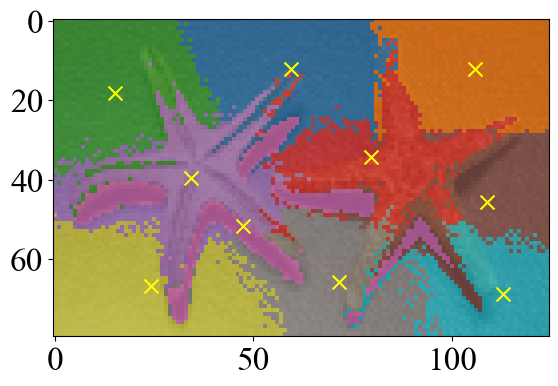

In [ ]:
plot_image_cluster(image_array, cluster_centers_indices, labels, n_clusters_,alpha=0.7, marker_color = 'yellow', save = True, name = image_name)

# Naive Attribution

In [ ]:
# Download ImageNet class index JSON file
# import requests

# url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
# output_file = "in_cls_idx.json"

# response = requests.get(url)
# response.raise_for_status()  # Check for download errors

# with open(output_file, "wb") as f:
#     f.write(response.content)

# print(f"Downloaded and saved as {output_file}")

Downloaded and saved as in_cls_idx.json


In [ ]:
import json

with open("in_cls_idx.json", "r") as f:
    imagenet_id_to_name = {int(cls_id): name for cls_id, (label, name) in json.load(f).items()}

# let's preview the first few class names
dict(sorted(imagenet_id_to_name.items())[: 10])

{0: 'tench',
 1: 'goldfish',
 2: 'great_white_shark',
 3: 'tiger_shark',
 4: 'hammerhead',
 5: 'electric_ray',
 6: 'stingray',
 7: 'cock',
 8: 'hen',
 9: 'ostrich'}

In [ ]:
# Load a pre-trained model from Torch Hub
use_GPU = True
if use_GPU:
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  print(f"Using device: {device}")
  torch.cuda.empty_cache() # clear cuda memory

# model = torch.hub.load("facebookresearch/swag", model="vit_h14_in1k")
# model = torch.hub.load("NVIDIA/DeepLearningExamples:torchhub", "nvidia_efficientnet_v2_m")
model = torchvision.models.efficientnet_v2_m(weights='DEFAULT')
# model = torchvision.models.googlenet(weights='DEFAULT')
# model = torchvision.models.vit_l_16(weights='DEFAULT')

# we also convert the model to eval mode
model.eval()
print('Model loaded')

Using device: cuda
Model loaded


Image shape: torch.Size([1, 3, 94, 125])
['banana', 'orange', 'lemon', 'grocery_store', 'slide_rule']


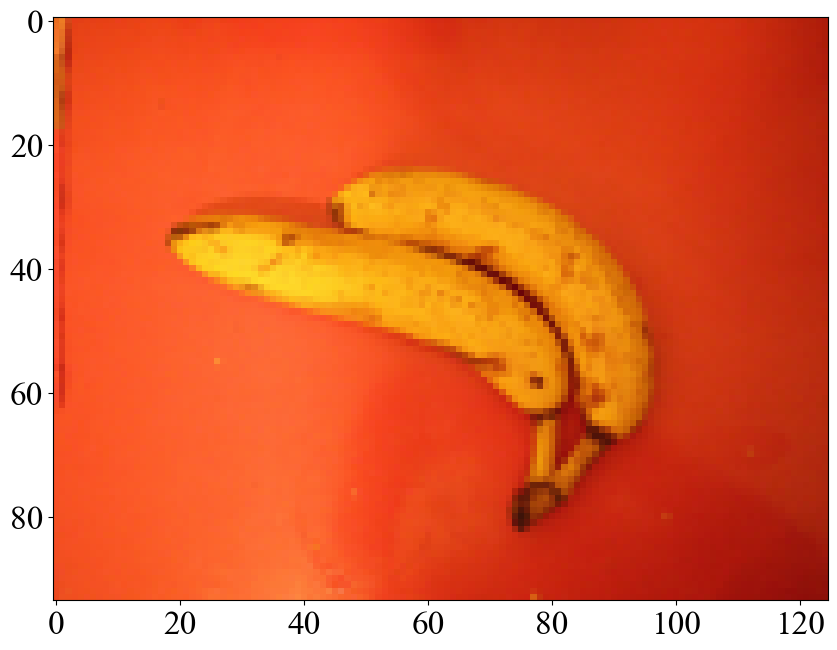

In [ ]:
image_name = "banana1"
# resolution = 200 # expected resolution 518
height = 94 # for banana
# height = 160 # for starfish
width = 125
image = visualize_and_transform(height,width, image_name+".JPEG")
classify_image(model, image, use_GPU = True)

In [ ]:
# Compute attribution value of each pixel
ig = captum.attr.IntegratedGradients(model)

ig_input = image
ig_input.requires_grad_()
ig_input = ig_input.to(device)

attr = ig.attribute(ig_input, target=1, n_steps=100)
attr = attr.cpu().detach().numpy()
print(attr.shape)
# Compute the absolute mean attribution value for each pixel across color channels
attr_abs_mean = np.mean(np.abs(attr), axis=(0,1)) # shape (height, width)

# Flatten the attribution values for ranking
attr_flattened = attr_abs_mean.flatten() # shape (height * width)

# Rank the pixels based on their attribution values (descending order)
ranked_pixels_indices = np.argsort(attr_flattened)[::-1]

print("Shape of flattened attribution values:", attr_flattened.shape)
print("Indices of top 10 ranked pixels:", ranked_pixels_indices[:10])

# Convert flattened indices back to 2D indices
# ranked_pixels_2d_indices = np.unravel_index(ranked_pixels_indices, (resolution, resolution))
ranked_pixels_2d_indices = np.unravel_index(ranked_pixels_indices, (height, width))

print("\nShape of 2D indices for all ranked pixels:", np.array(ranked_pixels_2d_indices).shape)
print("2D indices of top 10 ranked pixels (rows, columns):")
print(ranked_pixels_2d_indices[0][:30], ranked_pixels_2d_indices[1][:30])

(1, 3, 94, 125)
Shape of flattened attribution values: (11750,)
Indices of top 10 ranked pixels: [4571 6176 7073 6177 6051 4567 7204 4073 4696 5928]

Shape of 2D indices for all ranked pixels: (2, 11750)
2D indices of top 10 ranked pixels (rows, columns):
[36 49 56 49 48 36 57 32 37 47 50 40 34 36 48 57 33 34 59 47 37 33 36 40
 31 46 49 54 34 33] [71 51 73 52 51 67 79 73 71 53 87 83 73 68 53 73 70 75 76 45 81 69 69 82
 47 39 89 72 81 47]


(94, 125, 3)


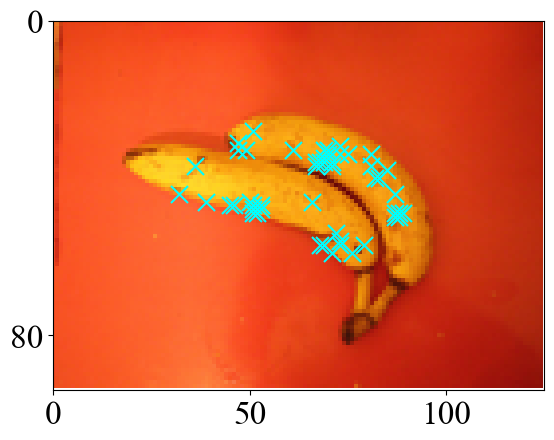

In [ ]:
# Plot top attribution pixels
save = True
image_array = load_image(image_name+".JPEG")
image_array = transform_image_simplify(image_array,height,width).numpy().transpose((1, 2, 0))
print(image_array.shape)
plt.imshow(image_array)
height, width, _ = image_array.shape
plt.scatter(ranked_pixels_2d_indices[1][:50],ranked_pixels_2d_indices[0][:50],marker='x',color='cyan',s=150, linewidths=1.5)
if save:
  plt.axis('off')
  plt.savefig(image_name+"_naive.png",format='png',bbox_inches='tight')
  plt.savefig(image_name+"_naive.eps",format='eps',bbox_inches='tight')
  plt.axis('on')
plt.xlim(0,width)
plt.ylim(height,0)
plt.yticks(range(0,height+1,80))
plt.xticks(range(0,width+1,50))
plt.show()